In [14]:
import pandas as pd

In [15]:
df = pd.read_csv("/content/fmcg_sales_marketing_profitability_2023_2025.csv")

In [16]:
print(df.shape)

(18240, 27)


In [17]:
df.head()

,Order_ID,Order_Date,Year,Quarter,Month,Month_Name,Region,Country,City,Sales_Person,...,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
0,FMCG-2025-000001,2025-09-26,2025,Q3,9,September,Oceania,Australia,Perth,Ethan Cole,...,73,8.47,8.94,618.31,66.05,314.09,43.03,563.03,139.86,24.84
1,FMCG-2024-000002,2024-10-09,2024,Q4,10,October,Asia,India,Mumbai,Meera Nair,...,99,2.89,9.86,286.11,35.26,123.79,23.89,257.90,74.96,29.07
2,FMCG-2024-000003,2024-07-06,2024,Q3,7,July,North America,USA,Los Angeles,Nina Booker,...,361,5.96,15.32,2151.56,171.46,1011.60,107.02,1821.94,531.86,29.19
3,FMCG-2024-000004,2024-05-25,2024,Q2,5,May,Europe,France,Paris,Oliver Kent,...,603,3.80,18.00,2291.40,118.39,1133.66,85.20,1878.95,541.70,28.83
4,FMCG-2023-000005,2023-08-10,2023,Q3,8,August,Europe,France,Lyon,Lucas Bennett,...,113,3.18,12.46,359.34,34.82,157.70,23.02,314.57,99.03,31.48


In [18]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

(18240, 27)
['Order_ID', 'Order_Date', 'Year', 'Quarter', 'Month', 'Month_Name', 'Region', 'Country', 'City', 'Sales_Person', 'Customer_Type', 'Sales_Channel', 'Promotion_Type', 'Product_Category', 'Brand', 'Product_Name', 'SKU', 'Units_Sold', 'Unit_Price_USD', 'Discount_Pct', 'Gross_Sales_USD', 'Marketing_Spend_USD', 'COGS_USD', 'Logistics_Cost_USD', 'Net_Revenue_USD', 'Profit_USD', 'Profit_Margin_Pct']
Order_ID               0
Order_Date             0
Year                   0
Quarter                0
Month                  0
Month_Name             0
Region                 0
Country                0
City                   0
Sales_Person           0
Customer_Type          0
Sales_Channel          0
Promotion_Type         0
Product_Category       0
Brand                  0
Product_Name           0
SKU                    0
Units_Sold             0
Unit_Price_USD         0
Discount_Pct           0
Gross_Sales_USD        0
Marketing_Spend_USD    0
COGS_USD               0
Logistics_Cost_US

In [19]:
df.describe()

,Year,Month,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
count,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000,18240.000000
mean,2024.001590,6.519024,212.909759,4.467254,12.935771,936.431746,85.741888,471.024278,54.031789,792.210526,181.412572,19.870780
std,0.816752,3.467308,202.102318,1.949341,5.735972,1045.606955,87.551045,537.351019,51.266996,861.237271,239.526879,10.569275
min,2023.000000,1.000000,5.000000,1.450000,0.000000,13.020000,1.810000,6.310000,1.080000,10.540000,-637.500000,-45.310000
25%,2023.000000,3.000000,70.000000,3.020000,8.710000,274.532500,33.495000,140.510000,21.370000,245.217500,32.345000,13.720000
50%,2024.000000,7.000000,139.000000,3.990000,12.690000,565.430000,61.385000,287.165000,38.985000,493.895000,91.890000,20.870000
75%,2025.000000,10.000000,288.000000,5.440000,16.850000,1213.835000,107.605000,599.790000,69.240000,1027.362500,239.117500,27.260000
max,2025.000000,12.000000,1366.000000,12.740000,28.000000,10634.120000,1767.710000,6473.330000,628.860000,8752.940000,2723.000000,44.490000


# **REGION WISE TOTAL PROFIT**

In [52]:
total_profit = df[['Region','Profit_USD']].groupby('Region').sum().sort_values('Profit_USD',ascending=False).head(10)

In [53]:
print(total_profit)

               Profit_USD
Region                   
Europe         1135420.40
North America   780169.10
Asia            670320.46
South America   404226.59
Oceania         318828.76


In [54]:
import matplotlib.pyplot as plt


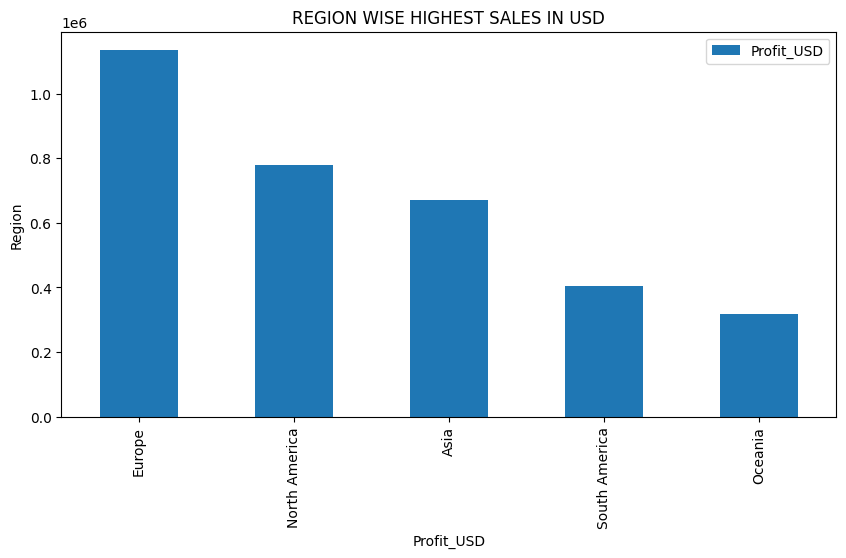

In [55]:
total_profit.plot(kind='bar',figsize=(10,5),title='REGION WISE HIGHEST SALES IN USD')
plt.xlabel('Profit_USD')
plt.ylabel('Region')
plt.show()

# **TOP 5 BEST SELLING PRODUCT CATEGORIES**

In [61]:
best_selling_categories = df[['Product_Category','Units_Sold']].groupby('Product_Category').sum().sort_values('Units_Sold',ascending=False).head(5)

In [62]:
print(best_selling_categories)

                   Units_Sold
Product_Category             
Beverages              981268
Snacks                 912058
Personal Care          686448
Household              683008
Dairy & Breakfast      620692


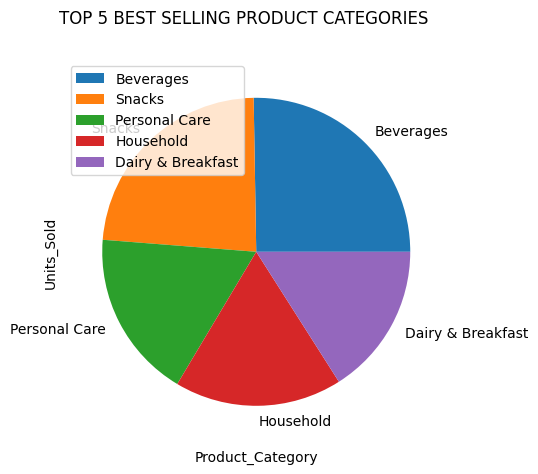

In [65]:
best_selling_categories.plot(kind='pie',figsize=(10,5),title='TOP 5 BEST SELLING PRODUCT CATEGORIES',subplots=True)
plt.xlabel('Product_Category')
plt.ylabel('Units_Sold')
plt.show()

# **Marketing Spend vs Profit **

In [74]:
profit = df['Marketing_Spend_USD'] == df['Profit_USD'].sum()

In [75]:
print(profit)

0        False
1        False
2        False
3        False
4        False
         ...  
18235    False
18236    False
18237    False
18238    False
18239    False
Name: Marketing_Spend_USD, Length: 18240, dtype: bool


Text(0, 0.5, 'Profit USD')

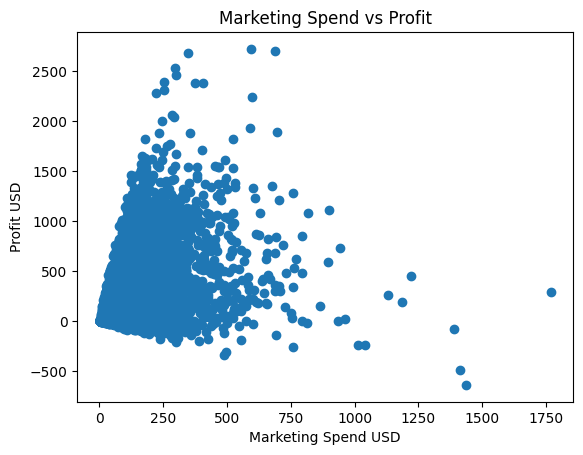

In [77]:
plt.scatter(df['Marketing_Spend_USD'],df['Profit_USD'])
plt.title('Marketing Spend vs Profit')
plt.xlabel('Marketing Spend USD')
plt.ylabel('Profit USD')

# **YEAR WISE REVENUE**

In [81]:
revenue_trend = df[['Year','Net_Revenue_USD']].groupby('Year').sum().sort_values('Year',ascending=False).head()

In [82]:
print(revenue_trend)

      Net_Revenue_USD
Year                 
2025       5016279.43
2024       4840333.97
2023       4593306.60


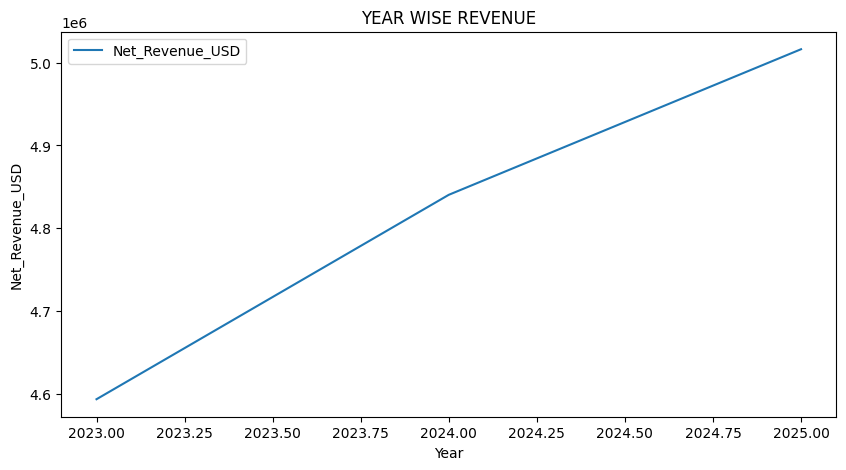

In [86]:
revenue_trend.plot(kind='line',figsize=(10,5),title='YEAR WISE REVENUE')
plt.xlabel('Year')
plt.ylabel('Net_Revenue_USD')
plt.show()

# **Sales Channel performance — Online vs Offline **

In [87]:
Performance = df[['Sales_Channel','Net_Revenue_USD']].groupby('Sales_Channel').sum().sort_values('Net_Revenue_USD',ascending=False).head()

In [88]:
print(Performance)

               Net_Revenue_USD
Sales_Channel                 
Wholesale           5208657.92
Distributor         4451811.56
Modern Trade        3371020.34
Online              1418430.18


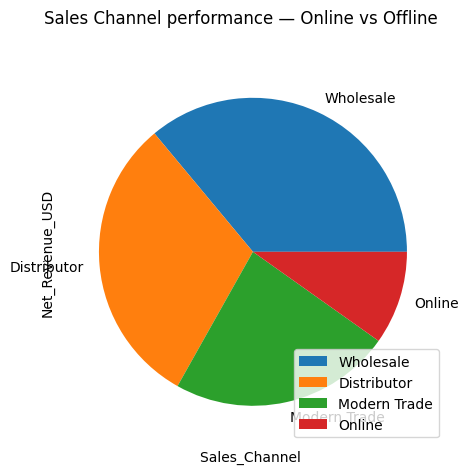

In [89]:
Performance.plot(kind='pie',figsize=(10,5),title='Sales Channel performance — Online vs Offline',subplots=True)
plt.xlabel('Sales_Channel ')
plt.ylabel('Net_Revenue_USD')
plt.show()

# **Which Promotion Type generates the highest profit?**

In [90]:
promotion = df[['Promotion_Type','Profit_USD']].groupby('Promotion_Type').sum().sort_values('Profit_USD',ascending=False).head()

In [91]:
print(promotion)

                   Profit_USD
Promotion_Type               
No Promo           1432411.66
Bundle Offer        487231.45
Seasonal Campaign   477538.93
Flash Discount      306545.88
Loyalty Cashback    281314.87


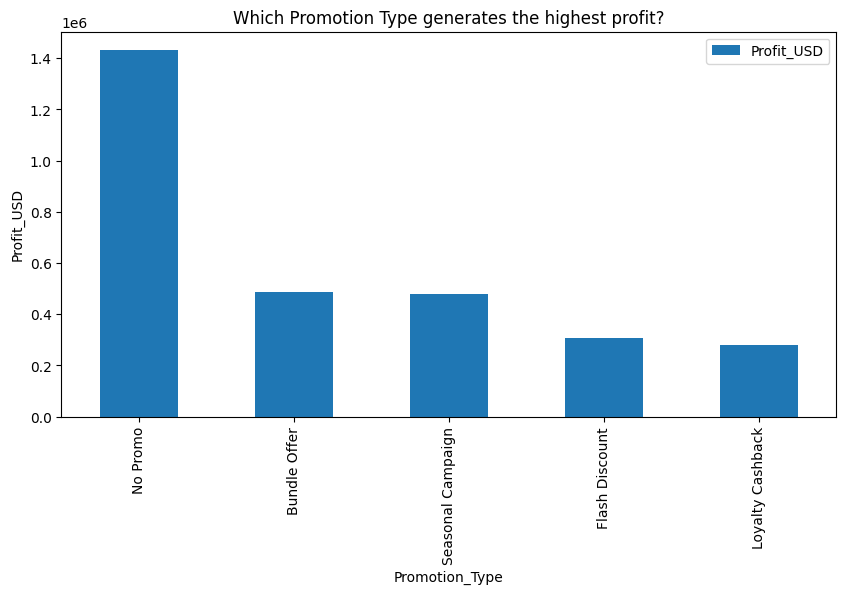

In [100]:
promotion.plot(kind='bar',figsize=(10,5),title='Which Promotion Type generates the highest profit?')
plt.xlabel('Promotion_Type')
plt.ylabel('Profit_USD')
plt.show()

# **Which Brand has the highest Profit Margin?**

In [95]:
brand_profit_margin = df[['Brand','Profit_Margin_Pct']].groupby('Brand').sum().sort_values('Profit_Margin_Pct',ascending=False).head(10)

In [96]:
print(brand_profit_margin)

             Profit_Margin_Pct
Brand                         
BrightSmile           34910.71
FreshNest             30102.20
NutriBite             29738.38
FuelCore              28789.49
FarmJoy               27577.59
SparkShield           27335.52
PureLiva              24326.73
MorningCo             24160.93
HomeNest              23701.14
Softora               22812.06


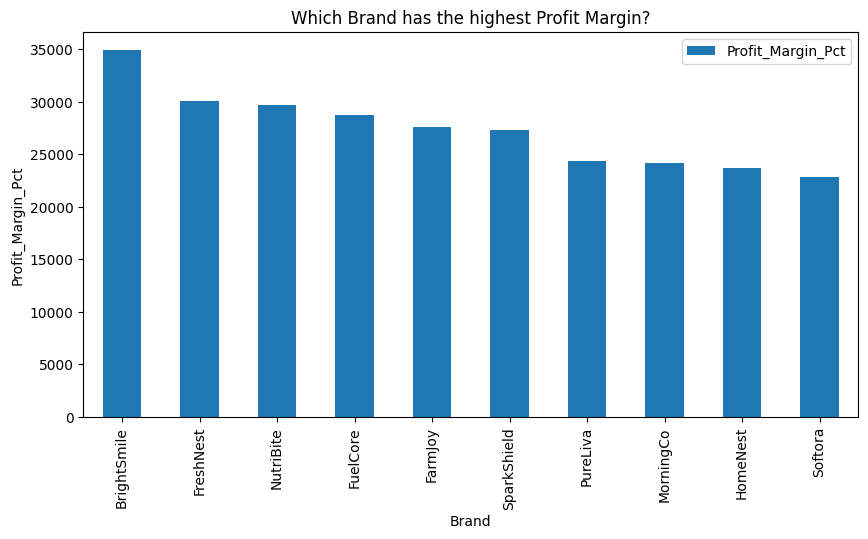

In [98]:
brand_profit_margin.plot(kind='bar',figsize=(10,5),title='Which Brand has the highest Profit Margin?')
plt.xlabel('Brand')
plt.ylabel('Profit_Margin_Pct')
plt.show()